# Rejection Sampling Example

We observe data:

$$
y_i \sim \mathcal{N}(\theta, 1)
$$

We place a Laplace prior on $\theta$:

$$
p(\theta) \propto e^{-|\theta|}
$$

The posterior distribution is proportional to:

$$
p(\theta \mid y)
\propto
\exp\left(
-\frac{n}{2}(\theta - \bar{y})^2 - |\theta|
\right)
$$

This distribution:

- Has no closed-form normalizing constant
- Has no inverse CDF
- Is not a standard distribution

We will sample from it using **rejection sampling**.

In [1]:
import numpy as np

np.random.seed(42)

n = 20
true_theta = 2.0

y = np.random.normal(true_theta, 1, size=n)
y_bar = np.mean(y)

print("Sample mean:", y_bar)

Sample mean: 1.828701438558171


We define the unnormalized posterior:

$$
\tilde{p}(\theta)
=
\exp\left(
-\frac{n}{2}(\theta - \bar{y})^2 - |\theta|
\right)
$$

Note that we do NOT compute the normalizing constant.

In [2]:
def target_unnormalized(theta):
    return np.exp(-0.5 * n * (theta - y_bar)**2 - np.abs(theta))

We choose a Gaussian proposal:

$$
q(\theta) = \mathcal{N}(\bar{y}, 1/n)
$$

This is easy to sample from and centered near the posterior mode.

In [3]:
proposal_mean = y_bar
proposal_std = 1 / np.sqrt(n)

def proposal_sample(size=1):
    return np.random.normal(proposal_mean, proposal_std, size=size)

def proposal_pdf(theta):
    return (
        1 / (proposal_std * np.sqrt(2 * np.pi))
        * np.exp(-0.5 * ((theta - proposal_mean) / proposal_std)**2)
    )

Rejection sampling requires:

$$
\tilde{p}(\theta) \le M q(\theta)
\quad \text{for all } \theta
$$

We compute:

$$
M = \max_\theta \frac{\tilde{p}(\theta)}{q(\theta)}
$$

numerically over a grid.

In [4]:
theta_grid = np.linspace(y_bar - 5, y_bar + 5, 10000)

ratio = target_unnormalized(theta_grid) / proposal_pdf(theta_grid)
M = np.max(ratio) * 1.1   # small safety margin

print("Estimated M:", M)

Estimated M: 0.6165375844272313


Algorithm:

1. Draw $\theta^* \sim q(\theta)$
2. Draw $u \sim \text{Uniform}(0,1)$
3. Accept $\theta^*$ if $u \le \frac{\tilde{p}(\theta^*)}{M q(\theta^*)} $

In [5]:
N_samples = 5000
samples = []
attempts = 0

while len(samples) < N_samples:
    theta_candidate = proposal_sample()[0]
    u = np.random.rand()
    attempts += 1

    acceptance_ratio = (
        target_unnormalized(theta_candidate)
        / (M * proposal_pdf(theta_candidate))
    )

    if u < acceptance_ratio:
        samples.append(theta_candidate)

samples = np.array(samples)

print("Acceptance rate:", N_samples / attempts)

Acceptance rate: 0.14932505077051728


## Visualizing the Envelope Condition

We verify that

$$
\tilde{p}(\theta) \le M q(\theta)
$$

for all $\theta$.

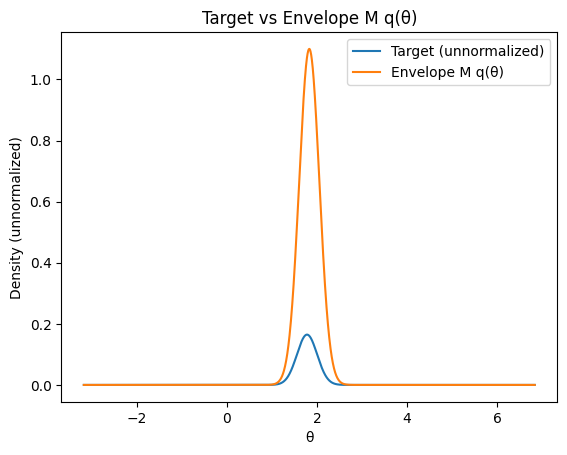

In [7]:
import matplotlib.pyplot as plt
import numpy as np

theta_grid = np.linspace(y_bar - 5, y_bar + 5, 2000)

plt.figure()
plt.plot(theta_grid, target_unnormalized(theta_grid))
plt.plot(theta_grid, M * proposal_pdf(theta_grid))
plt.title("Target vs Envelope M q(θ)")
plt.xlabel("θ")
plt.ylabel("Density (unnormalized)")
plt.legend(["Target (unnormalized)", "Envelope M q(θ)"])
plt.show()

## Comparing Samples to Target Distribution

We numerically normalize the target:

$$
p(\theta)
=
\frac{\tilde{p}(\theta)}
{\int \tilde{p}(\theta)\, d\theta}
$$

and compare it with the histogram of accepted samples.

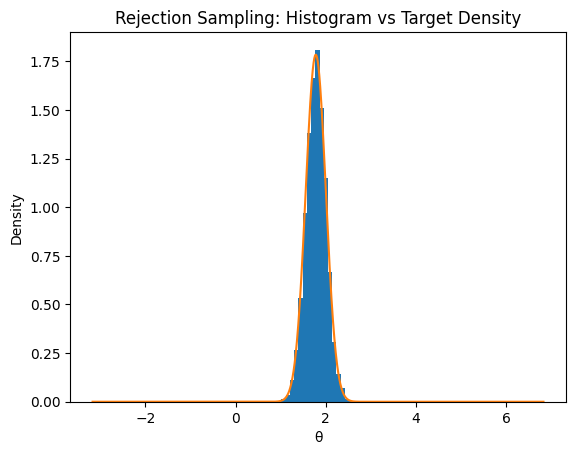

In [14]:
# Normalize target numerically
target_vals = target_unnormalized(theta_grid)
normalizing_constant = np.trapezoid(target_vals, theta_grid)
normalized_target = target_vals / normalizing_constant

plt.figure()
plt.hist(samples, bins=20, density=True)
plt.plot(theta_grid, normalized_target)
plt.title("Rejection Sampling: Histogram vs Target Density")
plt.xlabel("θ")
plt.ylabel("Density")
plt.show()

# Rejection Sampling with Empirical Densities

Suppose:

- We do not know analytical forms of either distribution.
- We only have empirical samples.

Let:

- $p(x)$ = weird target distribution (unknown formula)
- $q(x)$ = weird proposal distribution (unknown formula)

We approximate both using kernel density estimation (KDE).

Rejection sampling requires:

$$
p(x) \le M q(x)
$$

and we accept samples using:

$$
u \le \frac{p(x)}{M q(x)}
$$

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

np.random.seed(42)

# Create strange multimodal target distribution
target_data = np.concatenate([
    np.random.normal(-3, 0.5, 2000),
    np.random.normal(0, 1.0, 3000),
    np.random.normal(4, 0.7, 2000)
])

# Create strange proposal distribution
proposal_data = np.concatenate([
    np.random.normal(-2, 1.5, 4000),
    np.random.normal(3, 1.2, 4000)
])

## Visualizing the Empirical Data

We generated two strange, multimodal empirical datasets:

- Target data (unknown analytical density)
- Proposal data (unknown analytical density)

We visualize their raw distributions using histograms.

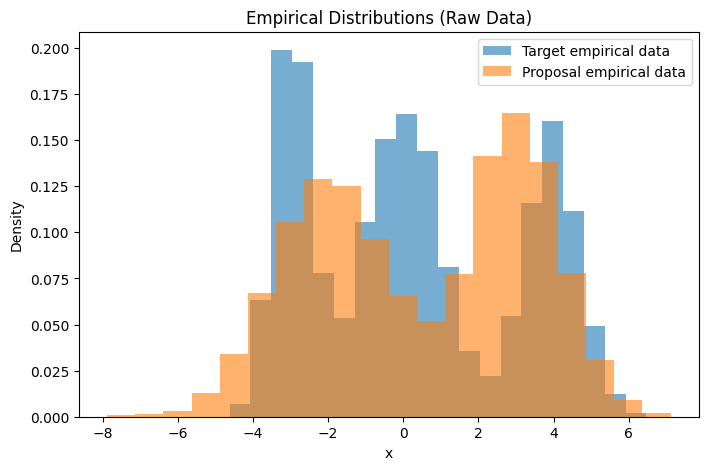

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Target histogram
plt.hist(target_data, bins=20, density=True, alpha=0.6, label="Target empirical data")

# Proposal histogram
plt.hist(proposal_data, bins=20, density=True, alpha=0.6, label="Proposal empirical data")

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Empirical Distributions (Raw Data)")
plt.legend()

plt.show()

In [27]:
# KDE estimators (no analytic formulas)
target_kde = gaussian_kde(target_data)
proposal_kde = gaussian_kde(proposal_data)

def p_hat(x):
    return target_kde(x)

def q_hat(x):
    return proposal_kde(x)

## Visualizing KDE Estimated Densities

We approximate the unknown densities using kernel density estimation:

$$
\hat p(x) = \text{KDE fitted to target data}
$$

$$
\hat q(x) = \text{KDE fitted to proposal data}
$$

We now visualize the estimated densities.

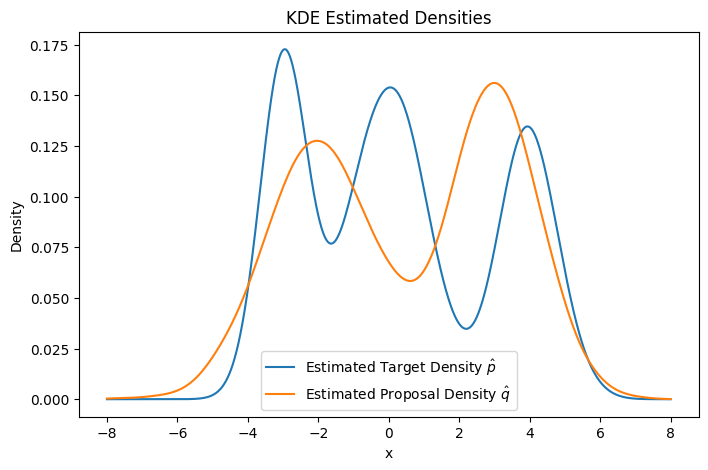

In [41]:
# Create grid for smooth curves
x_grid = np.linspace(-8, 8, 2000)

plt.figure(figsize=(8,5))

# Plot estimated densities
plt.plot(x_grid, p_hat(x_grid), label=r"Estimated Target Density $\hat{p}$")
plt.plot(x_grid, q_hat(x_grid), label=r"Estimated Proposal Density $\hat{q}$")

plt.xlabel("x")
plt.ylabel("Density")
plt.title("KDE Estimated Densities")
plt.legend()

plt.show()

In [28]:
# Grid search for envelope constant
x_grid = np.linspace(-8, 8, 5000)

ratio = p_hat(x_grid) / q_hat(x_grid)
M = np.max(ratio) * 1.1  # safety margin

print("Estimated M:", M)

Estimated M: 2.704190504052363


In [42]:
N_samples = 500
samples = []
attempts = 0

while len(samples) < N_samples:
    
    # Sample from empirical proposal (resampling)
    x_candidate = np.random.choice(proposal_data)
    u = np.random.rand()
    attempts += 1
    
    acceptance_ratio = p_hat(x_candidate) / (M * q_hat(x_candidate))
    
    if u < acceptance_ratio:
        samples.append(x_candidate)

samples = np.array(samples)

print("Acceptance rate:", N_samples / attempts)

Acceptance rate: 0.3586800573888092


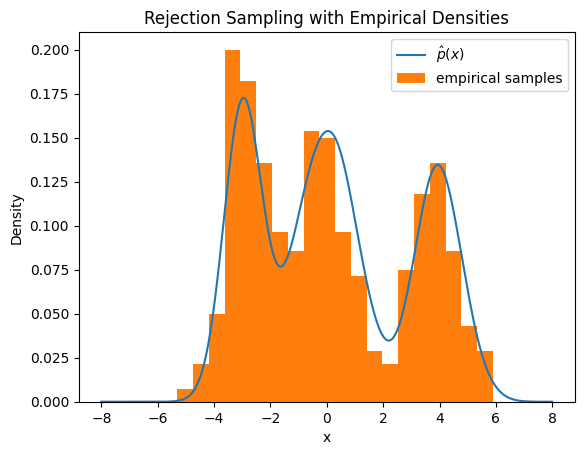

In [43]:
plt.figure()

# Target density
plt.plot(x_grid, p_hat(x_grid))

# Histogram of rejection samples
plt.hist(samples, bins=20, density=True)

plt.title("Rejection Sampling with Empirical Densities")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend([r"$\hat{p}(x)$", "empirical samples"])

plt.show()

# Importance Sampling Demonstration

Suppose our target distribution is a **standard Gaussian shifted by 2**:

$$
p(x) = \mathcal{N}(x \mid 2, 1)
$$

We want to estimate the expectation of a function, e.g.:

$$
\mu = \mathbb{E}_p[f(x)] = \int f(x) p(x) \, dx
$$

Let us choose 

$$
f(x) = x^2
$$

and a **proposal distribution**:

$$
q(x) = \mathcal{N}(x \mid 0, 2^2)
$$

which is easy to sample from but **does not match the target** exactly.

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

## Define target and proposal distributions

Target: 

$$
p(x) = \frac{1}{\sqrt{2\pi}} \exp\Big(-\frac{(x-2)^2}{2}\Big)
$$

Proposal: 

$$
q(x) = \frac{1}{\sqrt{2\pi} \cdot 2} \exp\Big(-\frac{x^2}{2\cdot 2^2}\Big)
$$

In [45]:
# Target distribution p(x)
def p(x):
    return norm.pdf(x, loc=2, scale=1)

# Proposal distribution q(x)
def q(x):
    return norm.pdf(x, loc=0, scale=2)

# Function f(x) whose expectation we want
def f(x):
    return x**2

## Draw samples from proposal

We draw \( N \) samples from \( q(x) \):

$$
x_i \sim q(x), \quad i=1,\dots,N
$$

We then compute the **importance weights**:

$$
w_i = \frac{p(x_i)}{q(x_i)}
$$

The importance sampling estimator of \(\mu\) is:

$$
\hat \mu = \frac{1}{N} \sum_{i=1}^N w_i f(x_i)
$$

In [46]:
N = 5000
x_samples = np.random.normal(loc=0, scale=2, size=N)

# Compute importance weights
w = p(x_samples) / q(x_samples)

# Estimate expectation
mu_hat = np.mean(w * f(x_samples))
print("Importance sampling estimate of E[f(x)]:", mu_hat)

Importance sampling estimate of E[f(x)]: 4.985278464530464


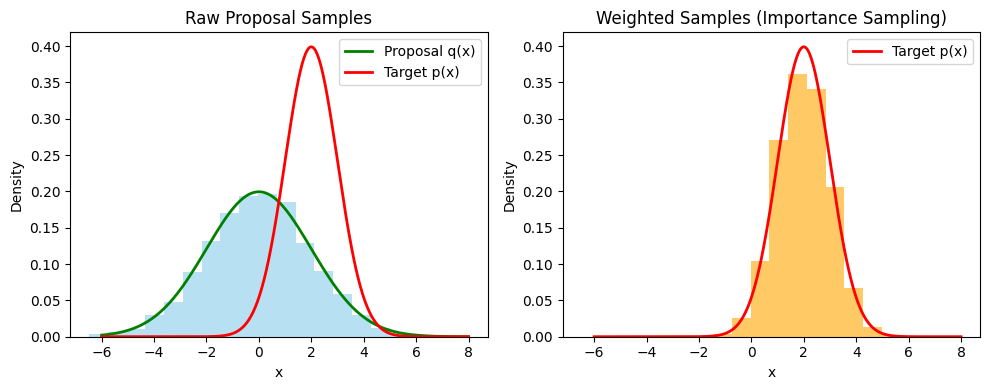

In [50]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,4))

# Left: raw proposal samples
plt.subplot(1,2,1)
plt.hist(x_samples, bins=20, density=True, alpha=0.6, color='skyblue')
plt.plot(x_grid, q(x_grid), 'g', lw=2, label='Proposal q(x)')
plt.plot(x_grid, p(x_grid), 'r', lw=2, label='Target p(x)')
plt.title("Raw Proposal Samples")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()

# Right: weighted histogram to approximate target
plt.subplot(1,2,2)
plt.hist(x_samples, bins=20, weights=w, density=True, alpha=0.6, color='orange')
plt.plot(x_grid, p(x_grid), 'r', lw=2, label='Target p(x)')
plt.title("Weighted Samples (Importance Sampling)")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

## Self-normalized Importance Sampling

If the target distribution is known only **up to a constant**, we can normalize the weights:

$$
\hat w_i = \frac{w_i}{\sum_{j=1}^N w_j}
$$

The self-normalized estimator:

$$
\hat \mu_{\rm SN} = \sum_{i=1}^N \hat w_i f(x_i)
$$

In [48]:
w_normalized = w / np.sum(w)
mu_hat_sn = np.sum(w_normalized * f(x_samples))
print("Self-normalized IS estimate of E[f(x)]:", mu_hat_sn)

Self-normalized IS estimate of E[f(x)]: 4.962972568535605


## Visualize the Samples and Importance Weights

- Histogram of proposal samples
- Scatter plot showing weights for each sample

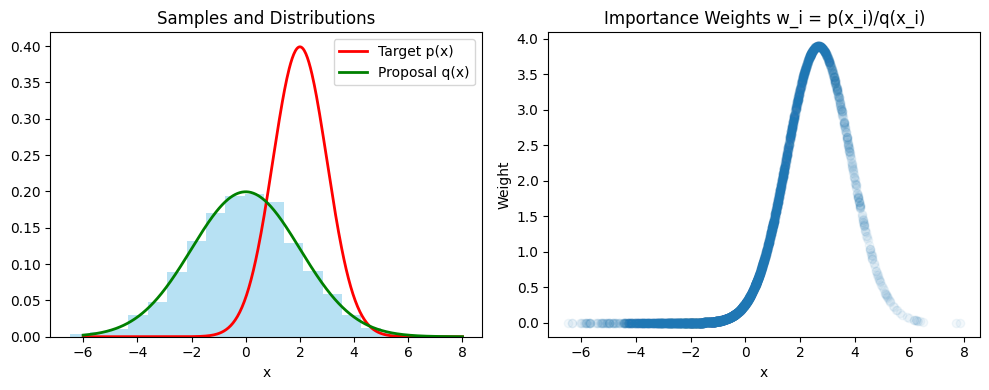

In [58]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(x_samples, bins=20, density=True, alpha=0.6, color='skyblue')
x_grid = np.linspace(-6,8,500)
plt.plot(x_grid, p(x_grid), 'r', lw=2, label="Target p(x)")
plt.plot(x_grid, q(x_grid), 'g', lw=2, label="Proposal q(x)")
plt.title("Samples and Distributions")
plt.xlabel("x")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(x_samples, w, alpha=0.05)
plt.title("Importance Weights w_i = p(x_i)/q(x_i)")
plt.xlabel("x")
plt.ylabel("Weight")

plt.tight_layout()
plt.show()

# Importance Sampling with Empirical Distributions

Suppose we **do not know the distributions analytically**, and we only have:

- `target_data` — samples from the target distribution $p(x)$
- `proposal_data` — samples from the proposal distribution $q(x)$

We want to estimate:

$$
\mu = \mathbb{E}_p[f(x)] = \int f(x) p(x)\, dx
$$

for some function, e.g.,

$$
f(x) = x^2
$$

using **importance sampling** with empirical densities estimated via KDE:

$$
\hat p(x) \approx p(x), \quad \hat q(x) \approx q(x)
$$

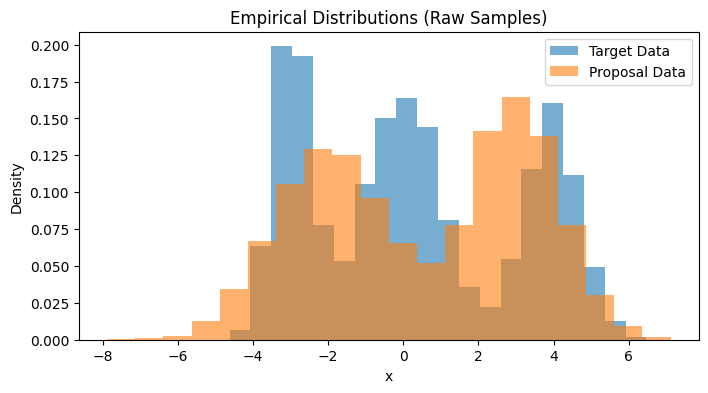

In [62]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

np.random.seed(42)

# Strange multimodal target distribution
target_data = np.concatenate([
    np.random.normal(-3, 0.5, 2000),
    np.random.normal(0, 1.0, 3000),
    np.random.normal(4, 0.7, 2000)
])

# Strange multimodal proposal distribution
proposal_data = np.concatenate([
    np.random.normal(-2, 1.5, 4000),
    np.random.normal(3, 1.2, 4000)
])

# Visualize raw data
plt.figure(figsize=(8,4))
plt.hist(target_data, bins=20, density=True, alpha=0.6, label="Target Data")
plt.hist(proposal_data, bins=20, density=True, alpha=0.6, label="Proposal Data")
plt.title("Empirical Distributions (Raw Samples)")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

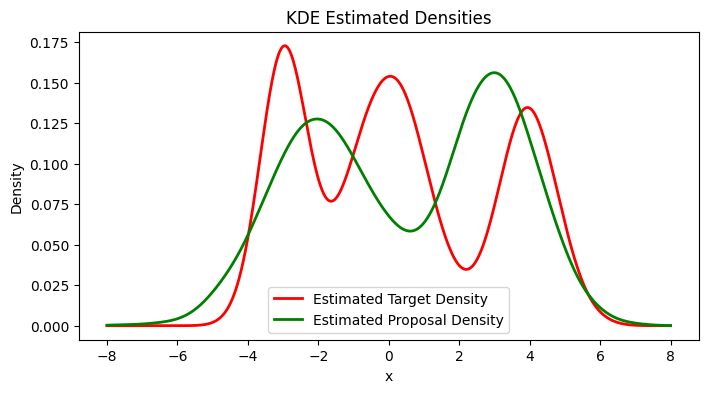

In [63]:
# Fit KDEs to estimate densities
target_kde = gaussian_kde(target_data)
proposal_kde = gaussian_kde(proposal_data)

# Define density functions
def p_hat(x):
    return target_kde(x)

def q_hat(x):
    return proposal_kde(x)

# Visualize estimated densities
x_grid = np.linspace(-8, 8, 2000)
plt.figure(figsize=(8,4))
plt.plot(x_grid, p_hat(x_grid), 'r', lw=2, label="Estimated Target Density")
plt.plot(x_grid, q_hat(x_grid), 'g', lw=2, label="Estimated Proposal Density")
plt.title("KDE Estimated Densities")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

In [64]:
# Draw samples from the proposal (resampling)
N = 500
x_samples = np.random.choice(proposal_data, size=N)

# Importance weights
w = p_hat(x_samples) / q_hat(x_samples)

# Function f(x) = x^2
f = lambda x: x**2

# Importance sampling estimate
mu_hat = np.mean(w * f(x_samples))
print("Importance sampling estimate of E[f(x)]:", mu_hat)

# Self-normalized weights (optional)
w_normalized = w / np.sum(w)
mu_hat_sn = np.sum(w_normalized * f(x_samples))
print("Self-normalized IS estimate of E[f(x)]:", mu_hat_sn)

Importance sampling estimate of E[f(x)]: 7.986942133214287
Self-normalized IS estimate of E[f(x)]: 7.861871622235407


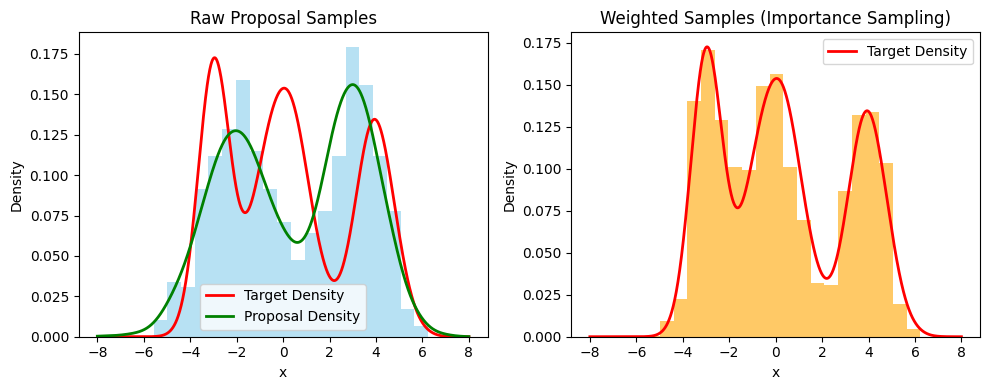

In [65]:
plt.figure(figsize=(10,4))

# Raw proposal histogram
plt.subplot(1,2,1)
plt.hist(x_samples, bins=20, density=True, alpha=0.6, color='skyblue')
plt.plot(x_grid, p_hat(x_grid), 'r', lw=2, label="Target Density")
plt.plot(x_grid, q_hat(x_grid), 'g', lw=2, label="Proposal Density")
plt.title("Raw Proposal Samples")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()

# Weighted histogram
plt.subplot(1,2,2)
plt.hist(x_samples, bins=20, weights=w, density=True, alpha=0.6, color='orange')
plt.plot(x_grid, p_hat(x_grid), 'r', lw=2, label="Target Density")
plt.title("Weighted Samples (Importance Sampling)")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

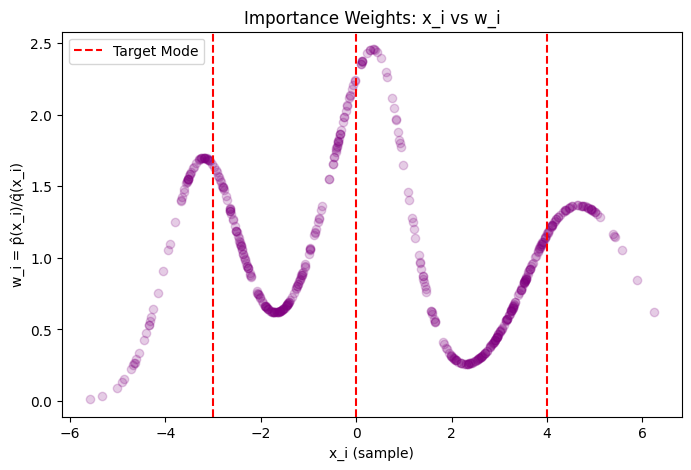

In [70]:
plt.figure(figsize=(8,5))
plt.scatter(x_samples, w, alpha=0.2, color='purple')
plt.title("Importance Weights: x_i vs w_i")
plt.xlabel("x_i (sample)")
plt.ylabel("w_i = p̂(x_i)/q̂(x_i)")

# Optional: vertical lines for main modes
plt.axvline(x=-3, color='red', linestyle='--', label='Target Mode')
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=4, color='red', linestyle='--')

plt.legend()
plt.show()